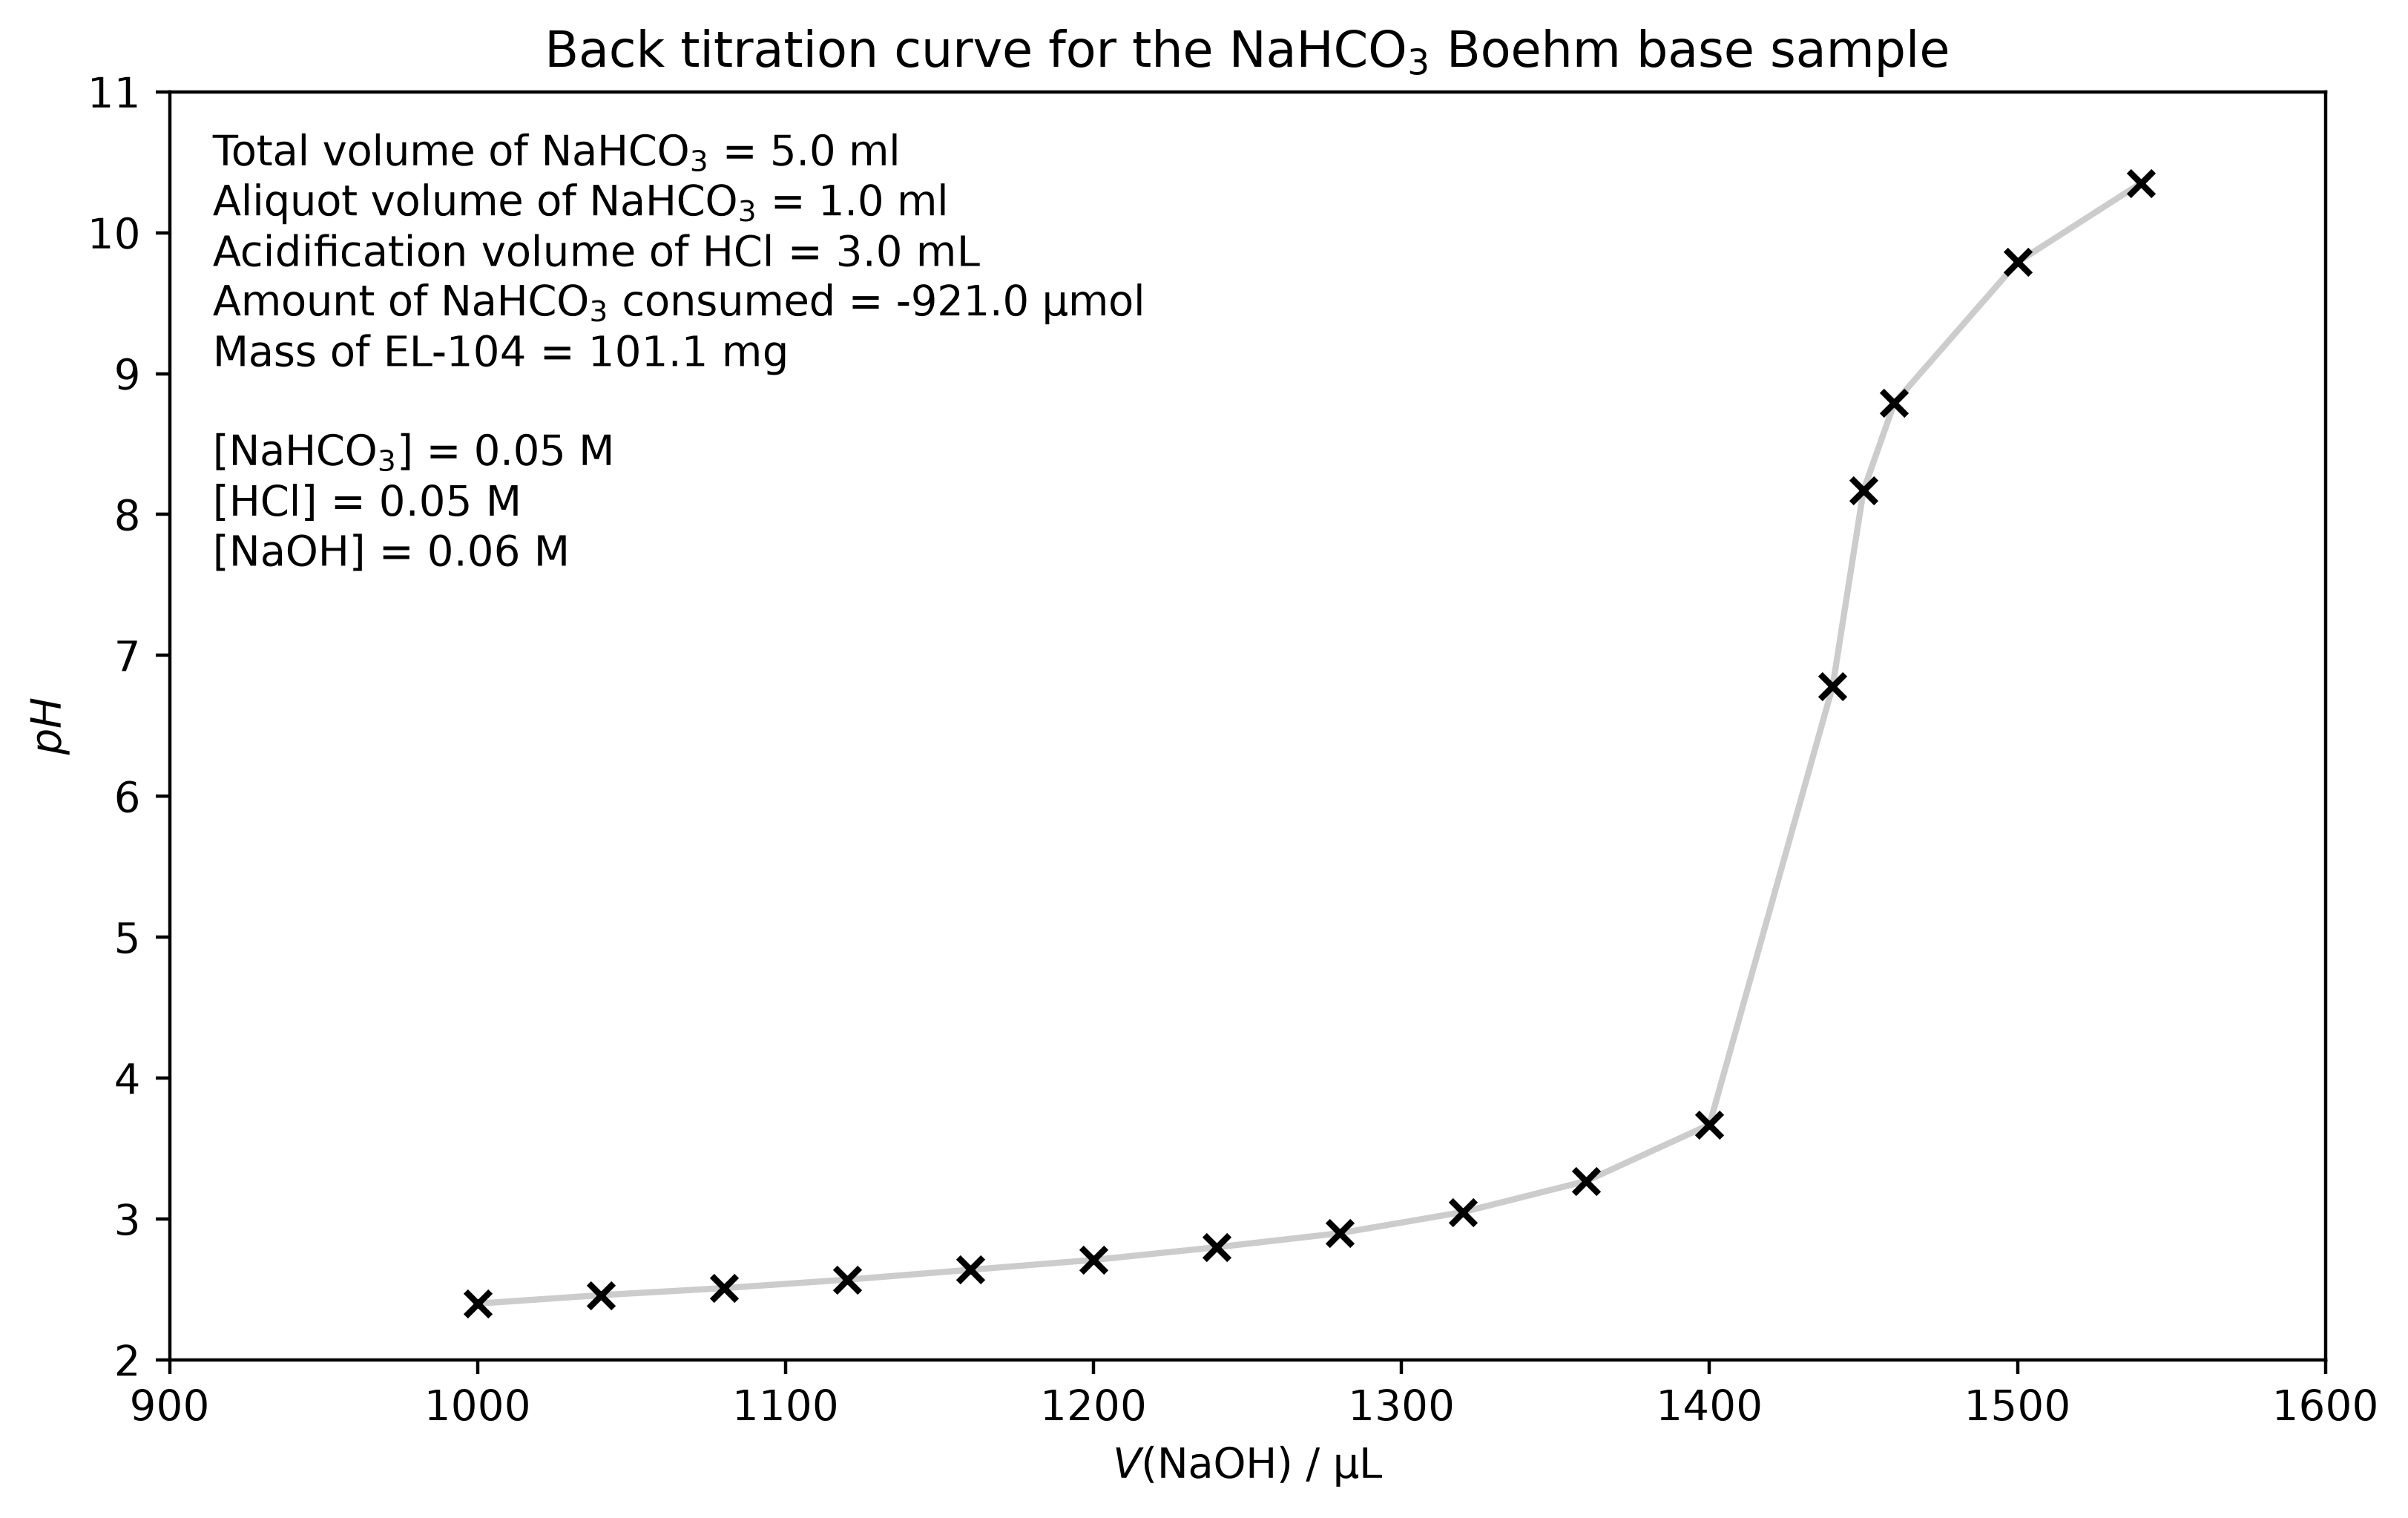

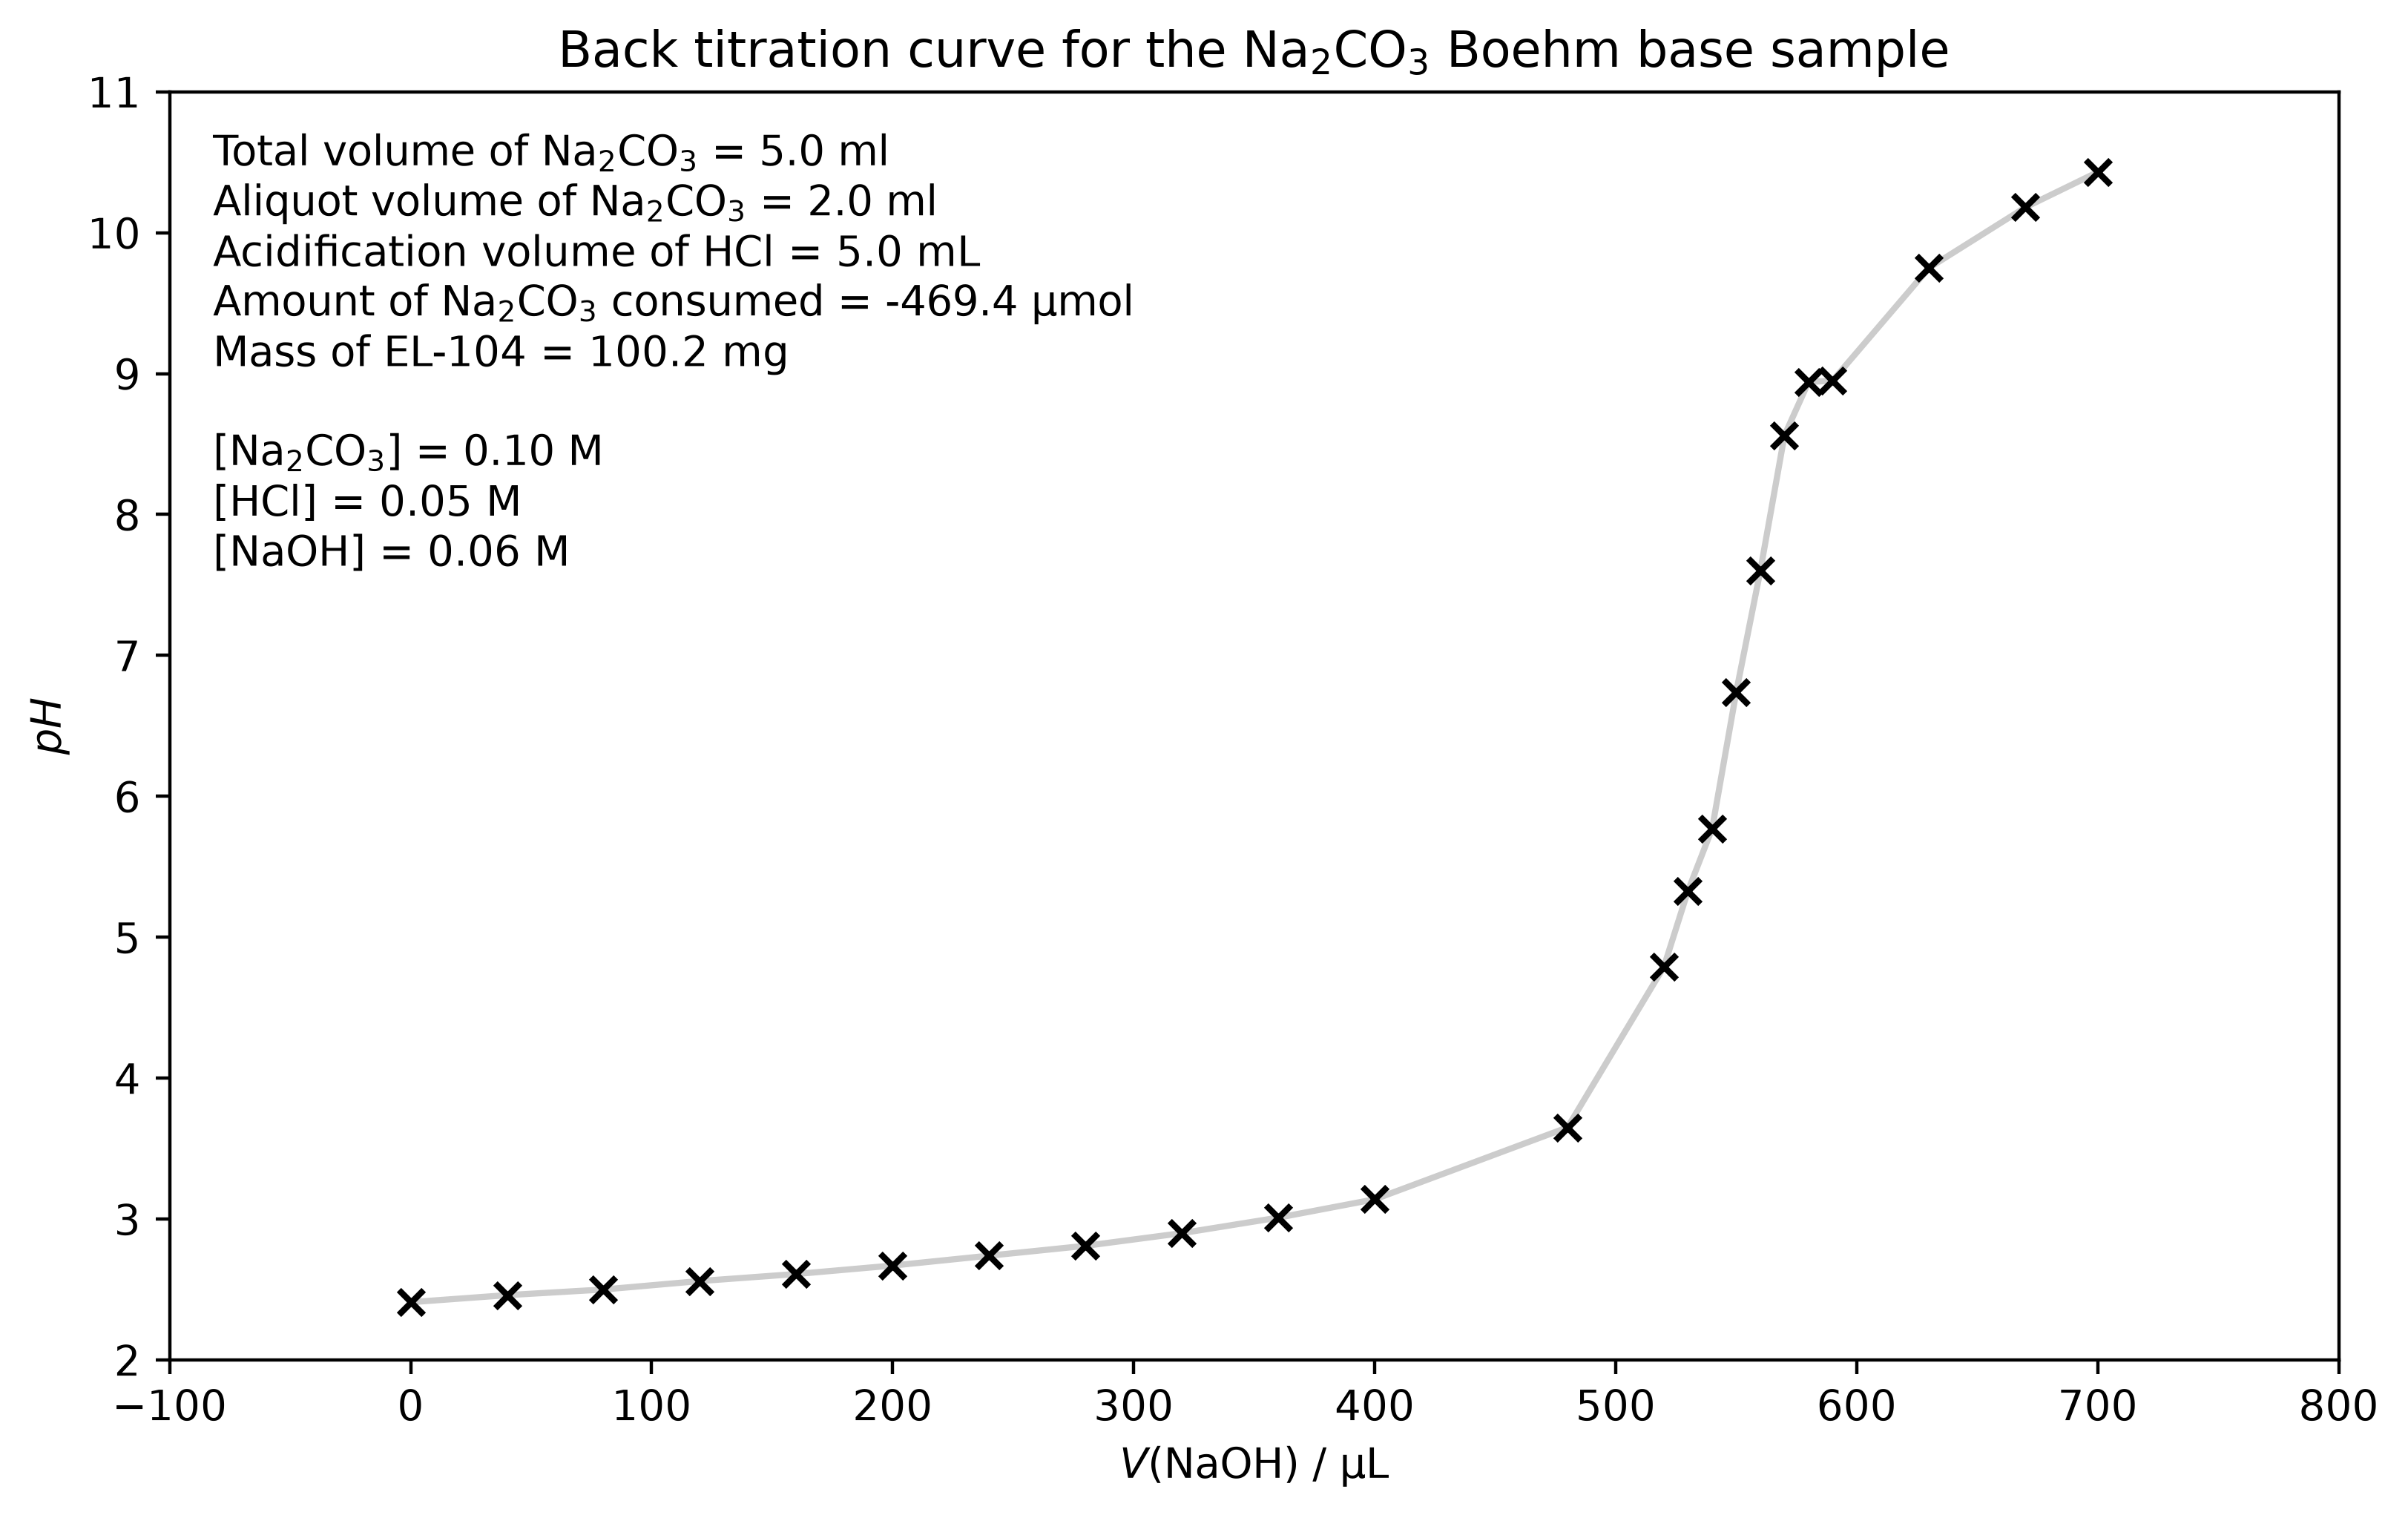

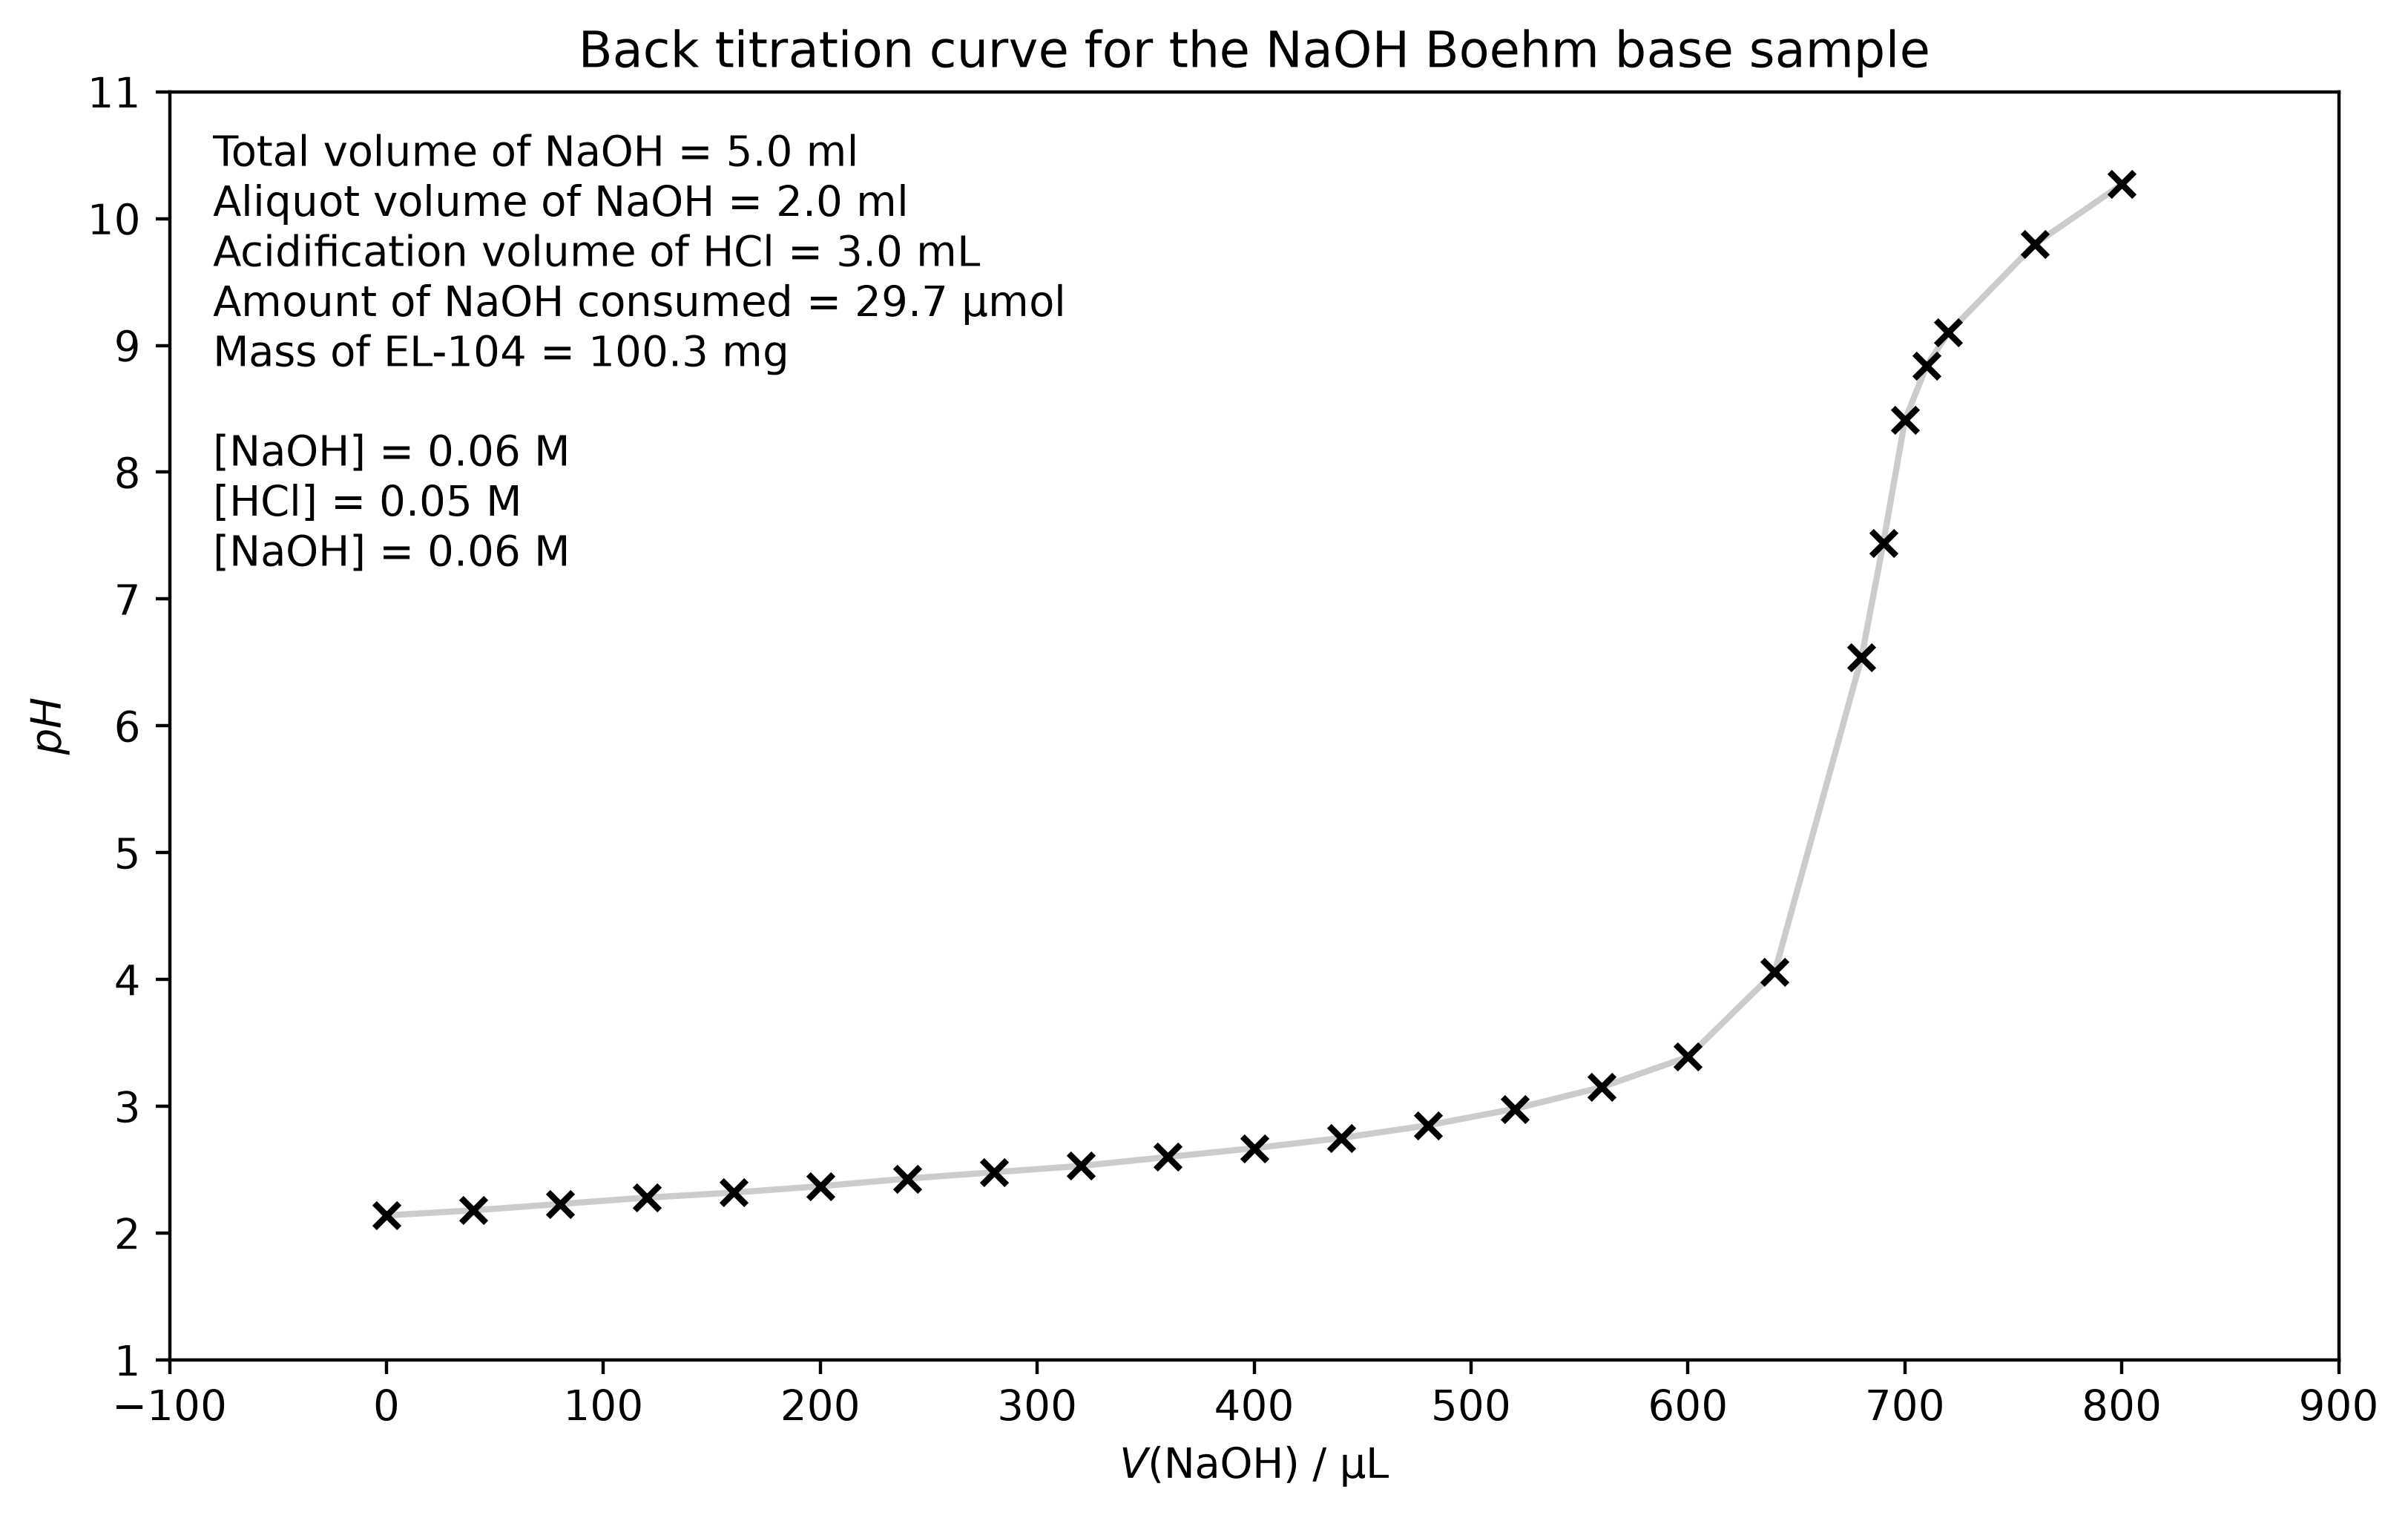

Amount of carboxylic acid groups = -921.0 μmol/g
Amount of lactonic groups = 451.6 μmol/g
Amount of phenolic groups = 499.1 μmol/g
Total amount of acidic surface functional groups = 29.7 μmol/g


In [ ]:
import numpy as np
from molmass import Formula
import matplotlib.pyplot as plt

"""
Constants
"""

FIGSIZE = (8, 5) # figure size for all plots
DPI = 400 # figure dpi resolution

# molar masses
M_NAHCO3 = Formula('NaHCO3').mass
M_NA2CO3 = Formula('Na2CO3').mass
M_NAOH = Formula('NaOH').mass

conchcl = 0.417*12/100 # 0.417 ul of 36.5-38% HCl in 100 ml of water
concnaoh = (225.4/M_NAOH)/100

"""
Dictionary of LaTeX text formatting for Matplotlib rendering, add new entries if necessary
"""
NAHCO3 = 'NaHCO$_3$'
NA2CO3 = 'Na$_2$CO$_3$'
NAOH ='NaOH'
HCL = 'HCl'

"""
Nested dictionary of each Boehm base and the parameters used in the experiment.
carbon: mass/g of activated carbon used,
conc: concentration/M of the Boehm base, calculated from mass/mg, M/g mol-1, volume/ml,
total: total volume/l of Boehm base used to submerge the activated carbon,
aliquot: volume/l of aliquot withdrawn after filtration for acidification and back titration,
acid: volume/l of HCl used for acidification,
titration: dictionary of NaOH volume/ul vs pH for back titration.
"""

nahco3 = {'carbon': 101.1e-3,
          'conc': (422.7*0.995/M_NAHCO3)/100,
          'total': 5e-3,
          'aliquot': 1e-3,
          'acid': 3e-3,
          'titration': {1000: 2.40, 1040: 2.46, 1080: 2.51, 1120: 2.57, 1160: 2.64, 1200: 2.71, 1240: 2.80, 1280: 2.90, 
                        1320: 3.05, 1360: 3.27, 1400: 3.67, 1440: 6.78, 1450: 8.17, 1460: 8.79, 1500: 9.79, 1540: 10.35}
         }

na2co3 = {'carbon': 100.2e-3,
          'conc': 2*(532.9*0.995/M_NA2CO3)/100, # effectively 2 moles of base per mole of Na2CO3
          'total': 5e-3,
          'aliquot': 2e-3,
          'acid': 5e-3,
          'titration': {0: 2.41, 40: 2.46, 80: 2.50, 120: 2.56, 160: 2.61, 200: 2.67, 240: 2.74, 280: 2.81, 320: 2.90, 360: 3.01, 400: 3.14, 480: 3.65,
                        520: 4.79, 530: 5.33, 540: 5.77, 550: 6.74, 560: 7.60, 570: 8.56, 580: 8.94, 590: 8.95, 630: 9.75, 670: 10.18, 700: 10.43}
         }

naoh = {'carbon': 100.3e-3,
        'conc': (225.4/M_NAOH)/100,
        'total': 5e-3,
        'aliquot': 2e-3,
        'acid': 3e-3,
        'titration': {0: 2.14, 40: 2.18, 80: 2.23, 120: 2.28, 160: 2.32, 200: 2.37, 240: 2.43, 280: 2.48, 320: 2.53, 360: 2.60, 400: 2.67, 440: 2.75,
                      480: 2.85, 520: 2.98, 560: 3.15, 600: 3.39, 640: 4.06, 680: 6.54, 690: 7.44, 700: 8.41, 710: 8.84, 720: 9.10, 760: 9.80, 800: 10.27}
       }

boehm = [(nahco3, NAHCO3, 1445), (na2co3, NA2CO3, 555), (naoh, NAOH, 685)]
moles = []

for info, base, veq in boehm:

    mol = ((info['aliquot']*info['conc']) + (veq*1e-6*concnaoh) - (info['acid']*conchcl))*(info['total']/info['aliquot'])/info['carbon']
    moles.append(mol)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, constrained_layout=True)
    ph = info['titration'].values()
    v = info['titration'].keys()
    ax.scatter(v, ph, color='black', marker='x') # plot data points
    ax.plot(v, ph, color='black', alpha=0.2) # plot titration curve
    ax.text(0.02, 0.97,
            f'Total volume of {base} = {info['total']*1e3:.1f} ml\n'
            f'Aliquot volume of {base} = {info['aliquot']*1e3:.1f} ml\n'
            f'Acidification volume of HCl = {info['acid']*1e3:.1f} mL\n'
            f'Amount of {base} consumed = {mol*1e6:.1f} μmol\n'
            f'Mass of EL-104 = {info['carbon']*1e3:.1f} mg\n\n'
            f'[{base}] = {info['conc']:.2f} M\n'
            f'[{HCL}] = {conchcl:.2f} M\n'
            f'[{NAOH}] = {concnaoh:.2f} M',
            transform=ax.transAxes, ha='left', va='top')

    fig.canvas.draw() # calculate ticks preliminarily
    xscale = np.diff(ax.get_xticks())[0]
    yscale = np.diff(ax.get_yticks())[0]
    xmin = np.floor((min(v)-0.3*xscale)/xscale)*xscale
    xmax = np.ceil((max(v)+0.3*xscale)/xscale)*xscale
    ymin = np.floor((min(ph)-0.3*yscale)/yscale)*yscale
    ymax = np.ceil((max(ph)+0.3*yscale)/yscale)*yscale

    ax.set_xlim(xmin, xmax)
    ax.set_xticks(np.arange(xmin, xmax+abs(1e-10*xmax), xscale))
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax+abs(1e-10*ymax), yscale))
    ax.set_xlabel('$V$(NaOH) / μL')
    ax.set_ylabel('$pH$')
    ax.set_title(f'Back titration curve for the {base} Boehm base sample')
    plt.show()

print(f'Amount of carboxylic acid groups = {moles[0]*1e6:.1f} μmol/g\n'
      f'Amount of lactonic groups = {(moles[1] - moles[0])*1e6:.1f} μmol/g\n'
      f'Amount of phenolic groups = {(moles[2] - moles[1])*1e6:.1f} μmol/g\n'
      f'Total amount of acidic surface functional groups = {(moles[2])*1e6:.1f} μmol/g')